# Risk Factor Expsoure

As always, any analysis based on historical risk exposures estimated from historical data may or may not affect the exposures going forward. This analysis is based on risk exposure, and risk exposure estimated from historical data is not enough. You **must** put confidence bounds on that risk exposure, and determine whether that risk exposure can be modeled reasonably. For more information on this, please see other lectures, especially on Instability of Parameter Estimates.

**Using Factor Models to Determine Risk Exposure**

We can use factor models to analyze the sources of risks and returns in portfolios. Recall that a factor model expresses the returns as:

$$
R_i = a_i + b_{i1}F_1 + b_{i2}F_2 + \dots + b_{iK}F_K + \epsilon_i
$$

By modeling the historical returns, we can see:
- how much of the portfolio is exposed to speculation on different factors
- fluctuations ($\epsilon_i$ — asset-specific risk)

In risk analysis, we often model **active returns** (returns relative to a benchmark) and **active risk** (standard deviation of active returns, also known as tracking error or tracking risk). For instance, we can find a factor's marginal contribution to active risk squared (**FMCAR**). For factor $j$ this is:

$$
\text{FMCAR}_j = b_j \cdot \frac{\sum_{k=1}^K b_k \text{Cov}(F_j, F_k)}{(\text{Active risk})^2}
$$

where $b_j$ is the portfolio's **active exposure** (exposure different from the benchmark's exposure) to factor $j$. This tells us how much risk we incur by being exposed to factor $j$, given all the other factors we're already exposed to. Fundamental factor models are often used for portfolios because they correspond directly to investment choices (e.g., small-cap vs large-cap stocks, value vs growth, etc.). To evaluate a single asset or for model construction, check out information on the fundamental factor models notebook.

We will use the canonical **Fama–French** factors as our example, which are the returns of portfolios constructed based on fundamental factors.

Import the libraries

In [103]:
import numpy as np
import statsmodels.api as sm
import pandas as pd
import yfinance as yf
import requests
import warnings

from matplotlib import pyplot as plt
from statsmodels import regression
from statsmodels.stats.stattools import jarque_bera
from statsmodels.regression.rolling import RollingOLS

warnings.filterwarnings("ignore")

Retrieve all the fundamentals of the various assets in the S&P500

In [87]:
# Define a function to get the fundamental data for a list of tickers
def get_fundamentals():
  url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
  headers = {
    "User-Agent": "Mozilla/5.0"
  }
  response = requests.get(url, headers=headers)
  tables = pd.read_html(response.text)
  tickers = tables[0]['Symbol'].tolist()

  # Download fundamentals in bulk
  data = {}

  for t in tickers:
    try:
      info = yf.Ticker(t).info
      data[t] = {
        "market_cap": info.get("marketCap"),
        "book_value": info.get("bookValue"),
        "price_to_book": info.get("priceToBook"),
        "book_to_price": 1 / info.get("priceToBook") if info.get("priceToBook") else None,
        "book_value_yield": info.get("bookValue") / info.get("currentPrice") if info.get("currentPrice") else None
      }
      data_df = pd.DataFrame.from_dict(data, orient="index")
      # Save it to a CSV file after each ticker to avoid losing data if the script is interrupted
      data_df.to_csv("sp500_fundamentals.csv")
    except Exception as e:
      pass
  return data_df

# Define a function that gets the price data of the input assets from Yahoo Finance
def get_prices(tickers, start_date, end_date):
  prices = yf.download(tickers, start=start_date, end=end_date)
  # Drop stocks that have NaN values in the 'Close' column (e.g., due to delisting or missing data)
  prices = prices["Close"].dropna(axis=1, how='any')
  return prices

# Check if we already have the fundamentals data saved locally to avoid unnecessary API calls
try:
  data = pd.read_csv("sp500_fundamentals.csv", index_col=0)
except Exception as e:
  data = get_fundamentals()

In [88]:
data.head(  )

,market_cap,book_value,price_to_book,book_to_price,book_value_yield
MMM,8.504099e+10,8.867,18.209091,0.054918,0.054918
AOS,1.077693e+10,13.411,5.810902,0.172090,0.172090
ABT,1.983044e+11,30.018,3.801719,0.263039,0.263039
ABBV,4.142112e+11,-1.850,-126.627020,-0.007897,-0.007897
ACN,1.277052e+11,50.162,4.105299,0.243588,0.243588


According to the Fama-French 3 Factor Model
- We will ignore assets wuth a negative book-to-price ratio
- We will get the top 30% and bottom 30% of stocks by market cap

Now as for the 3 Factors:
- **Factor 1**: (SMB-like): long top market-cap stocks, short bottom
- **Factor 2**: (HML-like): long top book-to-price stocks, short bottm
- **Factor 3**:

In [89]:
# According to the Fama-French three-factor model
start_date = '2021-01-31'
end_date = '2022-01-31'

fundamentals = data.copy()
fundamentals = fundamentals[fundamentals['book_value_yield'] > 0]
market_cap_top = fundamentals.sort_values("market_cap", ascending=False).head(int(0.1 * len(fundamentals))).index # Get the top 10% of stocks by market cap
market_cap_bottom = fundamentals.sort_values("market_cap", ascending=True).head(int(0.1 * len(fundamentals))).index # Get the bottom 10% of stocks by market cap

# Factor 1: Returns on portfolio that is long the top 10% of stocks by market cap and short the bottom 10% (SMB - Small Minus Big)
factor1 = (
  np.mean(get_prices(list(market_cap_top), start_date, end_date).pct_change().dropna(), axis=1) - \
    np.mean(get_prices(list(market_cap_bottom), start_date, end_date).pct_change().dropna(), axis=1))

# Repeat the above process for book-to-price ratio to get the second factor (HML - High Minus Low)
book_to_price_top = fundamentals.sort_values("book_to_price", ascending=False).head(int(0.1 * len(fundamentals))).index
book_to_price_bottom = fundamentals.sort_values("book_to_price", ascending=True).head(int(0.1 * len(fundamentals))).index
factor2 = (
  np.mean(get_prices(list(book_to_price_top), start_date, end_date).pct_change().dropna(), axis=1) - \
    np.mean(get_prices(list(book_to_price_bottom), start_date, end_date).pct_change().dropna(), axis=1))


[*********************100%***********************]  46 of 46 completed

1 Failed download:
['GEV']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-01-31 -> 2022-01-31) (Yahoo error = "Data doesn\'t exist for startDate = 1612069200, endDate = 1643605200")')
[*********************100%***********************]  46 of 46 completed

1 Failed download:
['SOLV']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-01-31 -> 2022-01-31) (Yahoo error = "Data doesn\'t exist for startDate = 1612069200, endDate = 1643605200")')
[*********************100%***********************]  46 of 46 completed
[*********************100%***********************]  46 of 46 completed

1 Failed download:
['GEV']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-01-31 -> 2022-01-31) (Yahoo error = "Data doesn\'t exist for startDate = 1612069200, endDate = 1643605200")')


Now that we have our factors, we can use the above information to model active returns (i.e asset returns minus benchmark returns)

In [90]:
# Specify and asset and a benchmark (e.g., S&P 500 index)
asset_ticker = "AAPL"
benchmark_ticker = "SPY"
asset_returns = get_prices([asset_ticker], start_date, end_date).pct_change().dropna()
benchmark_returns = get_prices([benchmark_ticker], start_date, end_date).pct_change().dropna()

# Compute the excess returns of the asset over the benchmark
excess_returns = asset_returns[asset_ticker] - benchmark_returns[benchmark_ticker]

# Define a constant term to compute the intercept
constant = np.ones(len(excess_returns))

new_df = pd.DataFrame({
  'R': excess_returns, 
  'F1': factor1, 
  'F2': factor2,
  'Const': constant}).dropna()

new_df.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,R,F1,F2,Const
Date,,,,
2021-02-02,-0.007804,-0.000640,-0.006920,1.0
2021-02-03,-0.008564,0.001648,0.010795,1.0
2021-02-04,0.014392,-0.000310,0.000156,1.0
2021-02-05,-0.007034,-0.003657,-0.003116,1.0
2021-02-08,-0.006125,0.001270,-0.001907,1.0


Perform the linear regression to get the coefficients in the model

In [91]:
b1, b2 = regression.linear_model.OLS(new_df['R'], new_df[['F1', 'F2']]).fit().params[:2]

# Print the coefficients (factor exposures)
print(f"Factor 1 (SMB) exposure - Market Cap: {b1}")
print(f"Factor 2 (HML) exposure - B/P: {b2}")

Factor 1 (SMB) exposure - Market Cap: 0.4526764290622073
Factor 2 (HML) exposure - B/P: -0.5454628719616438


Using the formula above, we will compute the factors' marginal contribution to active risk squared

In [92]:
def risk_contribution(factor1, factor2, active, b1, b2):
  cov = np.cov(factor1, factor2)
  ar_squared = active.std() ** 2
  fmcar1 = b1 * (b2 * cov[0, 1] + b1 * cov[0, 0]) / ar_squared
  fmcar2 = b2 * (b1 * cov[0, 1] + b2 * cov[1, 1]) / ar_squared
  return fmcar1, fmcar2

In [93]:
fmcar1, fmcar2 = risk_contribution(factor1, factor2, excess_returns, b1, b2)
print(f"Factor 1 (SMB) contribution to active risk: {fmcar1:.2%}")
print(f"Factor 2 (HML) contribution to active risk: {fmcar2:.2%}")

Factor 1 (SMB) contribution to active risk: 4.94%
Factor 2 (HML) contribution to active risk: 18.18%


The first factor has a smaller contribution to active risk squared, while the second accounts for about 6.2% of that risk. The rest can be attributed to active specific risk (i.e., factors that we did not take into account) or the asset's **idiosyncratic risk**. However, as we will look at only one data point, we are just looking at how the exposure to these factors changes over time. As we lose a tremendous amount of information from just looking at one data point.

**Key takeaway / important note:**
- Looking at a single point in time gives very limited insight  
- Risk exposures and factor loadings can (and usually do) change substantially over time  
- A more robust analysis requires looking at the **time series** of exposures  
- Single-period estimates are noisy and can be misleading without confidence intervals or stability checks

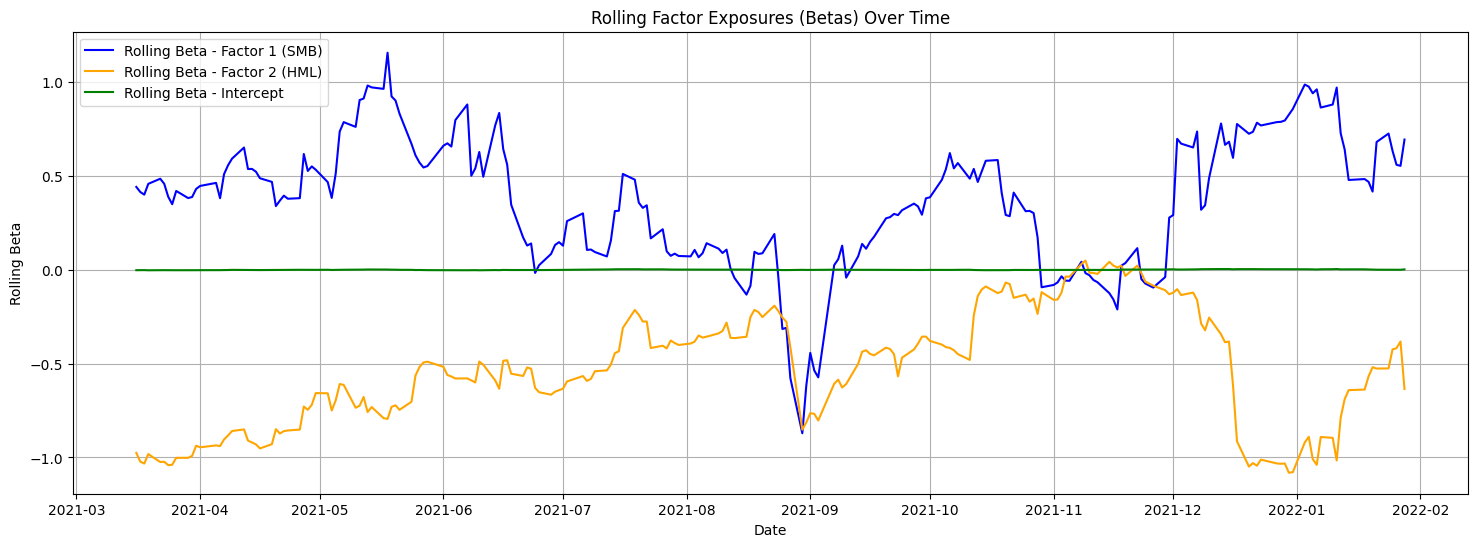

In [94]:
# Compute the rolling betas (factor exposures) over a 1-month window
X = sm.add_constant(new_df[['F1', 'F2']])
y = new_df['R']
rolling_window = 30
model = RollingOLS(y, X, window=30)
results = model.fit()
rolling_betas = results.params
rolling_betas.columns = ['Beta_Const', 'Beta_F1', 'Beta_F2']

# Plot the rolling betas to visualize how the factor exposures change over time
plt.figure(figsize=(18, 6))
plt.plot(rolling_betas.index, rolling_betas['Beta_F1'], label='Rolling Beta - Factor 1 (SMB)', color='blue')
plt.plot(rolling_betas.index, rolling_betas['Beta_F2'], label='Rolling Beta - Factor 2 (HML)', color='orange')
plt.plot(rolling_betas.index, rolling_betas['Beta_Const'], label='Rolling Beta - Intercept', color='green')
plt.title('Rolling Factor Exposures (Betas) Over Time')
plt.xlabel('Date')
plt.ylabel('Rolling Beta')
plt.legend()
plt.grid()
plt.show()

As we can see from the above graph, the betas for our factors change across time and window size. It is not fixed and this gives us more information on how risk-contribution will change as a result.

Let us now define a function to compute FMCAR for a given date

In [101]:
active_risk_squared = excess_returns.rolling(window=rolling_window).std() ** 2

# Remove the first few rows of the active risk series that are NaN due to the rolling window
active_risk_squared = active_risk_squared.dropna()

def compute_FMCAR(asset, benchmark, factor_df, factor_name, t, window=30):
    # Now assume t is integer position
    if t < window:
      raise ValueError("Not enough data points.")

    excess_returns = asset - benchmark
    y_window = excess_returns.iloc[t-window:t]
    X_window = factor_df.iloc[t-window:t]

    # Add constant if not already included
    X_window = sm.add_constant(X_window, has_constant='add')
    model = sm.OLS(y_window, X_window).fit()
    ar_squared = y_window.std() ** 2

    f_j = X_window[factor_name]
    b_j = model.params[factor_name]
    s = 0.0
    for factor in X_window.columns:
      b_factor = model.params[factor]
      s += b_factor * np.cov(f_j, X_window[factor])[0, 1]

    return b_j * s / ar_squared

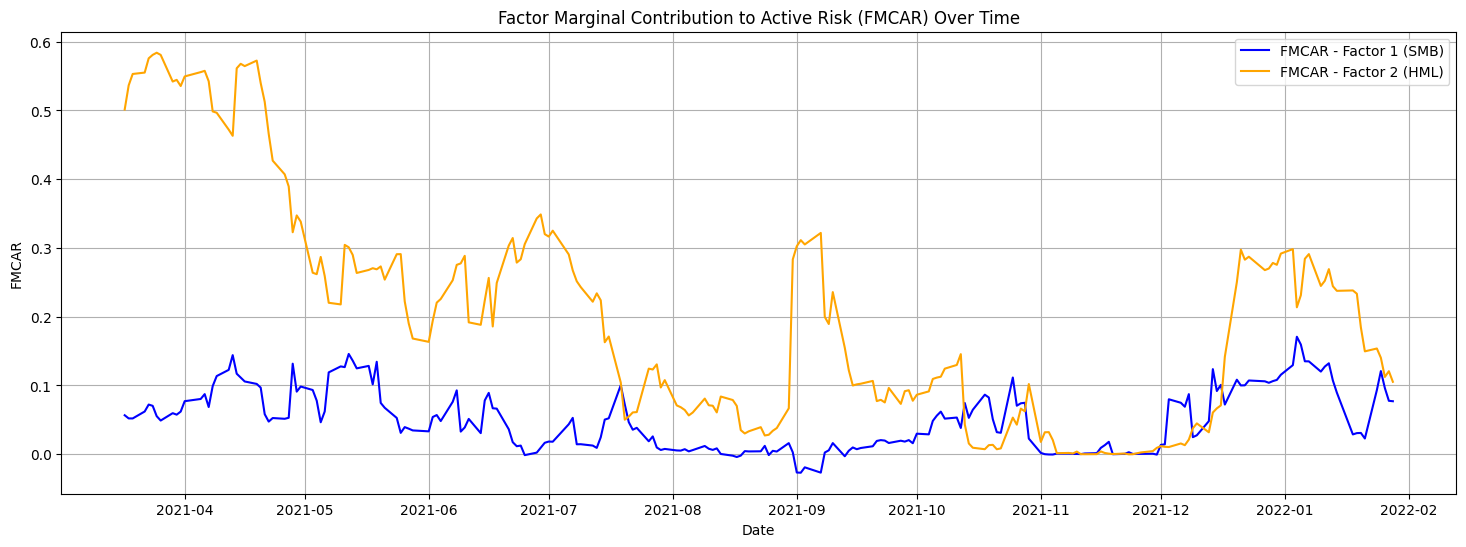

In [102]:
# Compute FMCAR for all time points in the rolling window
F1_FMCAR = [compute_FMCAR(asset_returns[asset_ticker], benchmark_returns[benchmark_ticker], new_df[['F1','F2']], 'F1', t, window=rolling_window) for t in range(rolling_window, len(new_df))]
F2_FMCAR = [compute_FMCAR(asset_returns[asset_ticker], benchmark_returns[benchmark_ticker], new_df[['F1','F2']], 'F2', t, window=rolling_window) for t in range(rolling_window, len(new_df))]

# Add the date index back to the FMCAR lists for plotting
F1_FMCAR = pd.Series(F1_FMCAR, index=new_df.index[rolling_window:])
F2_FMCAR = pd.Series(F2_FMCAR, index=new_df.index[rolling_window:])

# Plot the FMCAR for both factors over time
plt.figure(figsize=(18, 6))
plt.plot(F1_FMCAR.index, F1_FMCAR, label='FMCAR - Factor 1 (SMB)', color='blue')
plt.plot(F2_FMCAR.index, F2_FMCAR, label='FMCAR - Factor 2 (HML)', color='orange')
plt.title('Factor Marginal Contribution to Active Risk (FMCAR) Over Time')
plt.xlabel('Date')
plt.ylabel('FMCAR')
plt.legend()
plt.grid()
plt.show()

The graph shows the Factor Marginal Contribution to Active Risk squared (FMCAR) for two Fama-French-style factors — Factor 1 (SMB – Small Minus Big) in blue and Factor 2 (HML – High Minus Low book-to-market) in orange — over roughly April 2021 to February 2022.

Key observations:
- HML (orange line) starts very high (~0.50–0.60 in early 2021), meaning value factor exposure was contributing substantially to the portfolio's active (tracking) risk at that time. It then exhibits a strong downward trend through mid-2021, with several peaks and troughs, eventually dropping toward near-zero by late 2021 before rising again sharply in early 2022 (reaching ~0.30 again).
- SMB (blue line) remains much lower and more stable overall, generally fluctuating between ~0.00 and ~0.15 throughout the period, with only modest spikes (e.g., around mid-2021 and early 2022). This indicates size factor exposure contributed far less to active risk compared to the value factor in this portfolio/strategy.
- Both lines show noticeable time-variation and volatility in their risk contributions, highlighting that factor exposures and their importance to active risk are not static — they can change dramatically over just a few months.

In summary, during this ~11-month window the portfolio's active risk was dominated by value (HML) exposure for much of 2021, while size (SMB) played a consistently smaller role. The sharp swings, especially in HML, illustrate why single-point-in-time factor risk analysis can be misleading and why looking at the time series (as done here) is far more informative.

**Issues with using this data**

We would like to be able to make a meaningful statement about how exposed our asset is to these two factors. However, as we have seen from the above charts, the exposrue varies, and hence taking average would not be wise. We could put confidence intervals around the average, but that would only work if it is normally distributed. So, let us run the Jarque-Bera Normality Test 

**Jarque-Bera Normality Test on FMCAR Time Series**

We test whether the time series of Factor Marginal Contributions to Active Risk (FMCAR) for the two factors are normally distributed. This matters because many confidence interval methods assume normality of the underlying distribution.

In [106]:
_, pvalue1, skew1, kurtosis1 = jarque_bera(F1_FMCAR)
_, pvalue2, skew2, kurtosis2 = jarque_bera(F2_FMCAR)
print(f"Factor 1 (SMB) FMCAR - Jarque-Bera test p-value: {pvalue1:.9f}, Skewness: {skew1:.4f}, Kurtosis: {kurtosis1:.4f}")
print(f"Factor 2 (HML) FMCAR - Jarque-Bera test p-value: {pvalue2:.9f}, Skewness: {skew2:.4f}, Kurtosis: {kurtosis2:.4f}")

if pvalue1 < 0.05:
  print("Factor 1 (SMB) FMCAR is not normally distributed (reject null hypothesis).")
else:    
  print("Factor 1 (SMB) FMCAR is normally distributed (fail to reject null hypothesis).")
  
if pvalue2 < 0.05:
  print("Factor 2 (HML) FMCAR is not normally distributed (reject null hypothesis).")
else:  
  print("Factor 2 (HML) FMCAR is normally distributed (fail to reject null hypothesis).")

Factor 1 (SMB) FMCAR - Jarque-Bera test p-value: 0.000585874, Skewness: 0.5070, Kurtosis: 2.2330
Factor 2 (HML) FMCAR - Jarque-Bera test p-value: 0.000012878, Skewness: 0.7733, Kurtosis: 2.7678
Factor 1 (SMB) FMCAR is not normally distributed (reject null hypothesis).
Factor 2 (HML) FMCAR is not normally distributed (reject null hypothesis).


**Interpretation of Jarque-Bera Test Results & Implications**

The p-values are **well below** our default cutoff of 0.05 (actually extremely small: on the order of 10⁻¹⁹ to 10⁻²²). We **strongly reject** the null hypothesis that the FMCAR time series for either factor is normally distributed.

**Consequences for risk management and hedging:**
- We **cannot** reliably construct standard confidence intervals around the average risk exposure to these factors (because those intervals assume approximate normality of the distribution).
- A point estimate or simple historical average of exposure is **very noisy** and potentially misleading.
- Predicting future exposure to these factors is **extremely difficult** right now.
- Any hedge that was put on to neutralize (cancel out) exposure to one or both of these factors **might be way over-hedged or under-hedged** in the near future.
- We are essentially trying to **predict future exposures** based on past behavior — but given the non-normality and high time-variation we’ve already observed, such predictions carry **very high uncertainty**.

**Bottom line / important caution:**

One must be **very careful** with statistical methods and predictions in this setting. False confidence in stable exposures or reliable hedges can lead to significant risk mismanagement.